# Задание №6. Создание нейронной сети для анализа тональности отзывов (Sentiment Analysis с LSTM)


**Выполнил:** Асламин В.В.


**Группа:** МОм-24-1


**Дата:** 2026


**Ссылка на репозиторий:** https://github.com/mystic-solis/deep-learning

---

## 1. Введение


**Цель работы:** построить и обучить модель для анализа тональности текстовых отзывов с использованием рекуррентных нейронных сетей (LSTM).


**Задачи:**
- Подготовить размеченный корпус отзывов
- Построить модель LSTM/BiLSTM для классификации тональности
- Обучить модель и оценить её качество
- Реализовать функцию предсказания тональности новых отзывов
- Сохранить модель и загрузить её из репозитория

## 2. Теоретическая часть

### 2.1. Анализ тональности (Sentiment Analysis)

Анализ тональности — задача обработки естественного языка (NLP), целью которой является автоматическое определение эмоциональной окраски текста (позитивная, негативная, нейтральная).

### 2.2. Токенизация (Tokenization)

Процесс разбиения текста на минимальные единицы — токены (слова, знаки препинания).

### 2.3. Эмбеддинги (Embeddings)

Векторные представления слов. Слой Embedding преобразует индексы токенов в плотные векторы фиксированной размерности.

### 2.4. LSTM (Long Short-Term Memory)

Разновидность рекуррентных нейронных сетей, которая эффективно обучается на длинных последовательностях, избегая проблемы затухания градиента.

### 2.5. Метрики качества

- **Accuracy** — доля правильных ответов
- **Precision** — доля истинно-положительных среди всех предсказанных положительных
- **Recall** — доля найденных положительных примеров
- **F1-score** — гармоническое среднее precision и recall

## 3. Описание данных

### 3.1. Источник данных

В данной работе используется файл `reviews.csv`, содержащий тексты отзывов и метки тональности (positive, negative, neutral).

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import requests
import io
import os
from pathlib import Path
import random


print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [2]:
# Загрузка данных из локального файла reviews.csv
data_path = Path('./reviews.csv')

df = pd.read_csv(data_path, encoding='utf-8')
df['text'] = df['review']
df["sentiment"] = pd.cut(
    df["rating"],
    bins=[0, 2, 3, 5],
    labels=["negative", "neutral", "positive"]
)
print("Данные загружены из файла reviews.csv")
print(f"Загружено отзывов: {len(df)}")

print("Первые 5 строк:")
df.head()

Данные загружены из файла reviews.csv
Загружено отзывов: 7540
Первые 5 строк:


,Unnamed: 0,title,userName,rating,review,date,isEdited,developerResponse,text,sentiment
0,0,Отличное приложение,Anechkina_smile,5,Я очень довольна. Даже не могу придумать минус...,2017-04-25 06:53:10,False,NaN,Я очень довольна. Даже не могу придумать минус...,positive
1,1,Верните как было,Li$$,1,Хватит забивать приложение и нагружать его вся...,2019-01-12 07:52:02,False,NaN,Хватит забивать приложение и нагружать его вся...,negative
2,2,Дно,Dykis,1,"Вы настолько мразотный банк, что даже нигде не...",2020-05-31 16:32:19,False,"{'id': 15686705, 'body': 'Мы рассказали об это...","Вы настолько мразотный банк, что даже нигде не...",negative
3,3,Фууууу,пренорвв,1,Че за бред комиссия за перевод внутри банка в ...,2019-08-27 15:39:14,False,NaN,Че за бред комиссия за перевод внутри банка в ...,negative
4,4,Разгрузите приложение,Eduardazizov,1,"Уберите все те сомнительные функции, которые д...",2018-10-27 17:27:52,False,NaN,"Уберите все те сомнительные функции, которые д...",negative


### 3.2. Статистика данных

In [3]:
# Статистика по данным
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

# Распределение классов
print("\nРаспределение классов:")
class_counts = df['sentiment'].value_counts()
print(class_counts)

# Процентное распределение
print("\nПроцентное распределение:")
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

# Средняя длина текста
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print(f"\nСредняя длина текста (в словах): {df['text_length'].mean():.2f}")
print(f"Минимальная длина: {df['text_length'].min()}")
print(f"Максимальная длина: {df['text_length'].max()}")

СТАТИСТИКА ДАННЫХ

Распределение классов:
sentiment
negative    4953
positive    1902
neutral      685
Name: count, dtype: int64

Процентное распределение:
sentiment
negative    65.7
positive    25.2
neutral      9.1
Name: proportion, dtype: float64

Средняя длина текста (в словах): 26.86
Минимальная длина: 1
Максимальная длина: 297


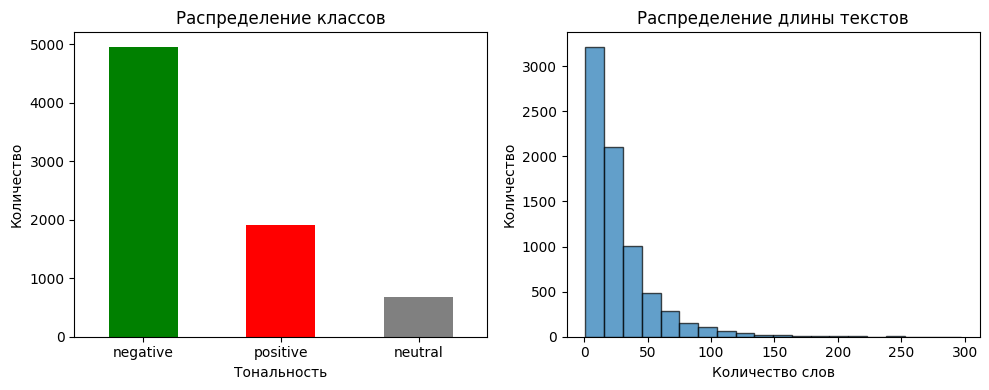

In [4]:
# Визуализация распределения классов
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Распределение классов')
plt.xlabel('Тональность')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.hist(df['text_length'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение длины текстов')
plt.xlabel('Количество слов')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

## 4. Подготовка данных

In [5]:
# Функция для очистки текста
def clean_text(text):
    text = str(text).lower()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("Текст очищен")

# Параметры токенизации
VOCAB_SIZE = 10000  # максимальный размер словаря
MAX_LENGTH = 20    # максимальная длина текста (в словах)

# Токенизация
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')


# Кодирование меток
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)


print(f"Классы: {label_encoder.classes_}")
print(f"Число классов: {num_classes}")
print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")

Текст очищен
Классы: ['negative' 'neutral' 'positive']
Число классов: 3
Форма X: (7540, 20)
Форма y: (7540,)


In [6]:
# Разделение на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Обучающих примеров: {len(X_train)}")
print(f"Тестовых примеров: {len(X_test)}")

print("\nРаспределение классов в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {label_encoder.classes_[cls]}: {cnt}")

Обучающих примеров: 6032
Тестовых примеров: 1508

Распределение классов в обучающей выборке:
  negative: 3962
  neutral: 548
  positive: 1522


## 5. Построение модели

In [ ]:
from keras.models import Model
from keras.layers import (
    Input, Embedding, Bidirectional, LSTM, GRU,
    Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
)
from keras.regularizers import l2

# Параметры модели
EMBEDDING_DIM = 128
LSTM_UNITS = 128

# Вход
inputs = Input(shape=(MAX_LENGTH,))
# Embedding с masking
x = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(inputs)
# Регуляризация эмбеддингов
x = SpatialDropout1D(0.3)(x)
# Первый BiLSTM (возвращает последовательность)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
# Второй слой (можно GRU вместо LSTM)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
# Пулинг (альтернатива attention)
x = GlobalMaxPooling1D()(x)
# Полносвязный блок
x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
# Выход
outputs = Dense(num_classes, activation='softmax')(x)
# Модель
model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

r:\projects\homework\.venv\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 128)   │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 20, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 20)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 20, 256)   │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 20, 256)   │    394,240 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional_1[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,954,051 (7.45 MB)

 Trainable params: 1,954,051 (7.45 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

In [8]:
# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# Обучение модели
print("Начало обучения модели...")

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Обучение завершено!")

Начало обучения модели...
Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6578 - loss: 0.8575 - val_accuracy: 0.7100 - val_loss: 0.7691
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7478 - loss: 0.6810 - val_accuracy: 0.7299 - val_loss: 0.7619
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8060 - loss: 0.5316 - val_accuracy: 0.7067 - val_loss: 0.8203
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8446 - loss: 0.4071 - val_accuracy: 0.7051 - val_loss: 0.8813
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8827 - loss: 0.3165 - val_accuracy: 0.6819 - val_loss: 1.1676
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9132 - loss: 0.2497 - val_accuracy: 0.6736 - val_loss: 1.1988
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9299 - loss: 0.1999 - val_accuracy: 0.6587 - val_loss: 1.4028
Обучение завершено!


### 6.1. Визуализация процесса обучения

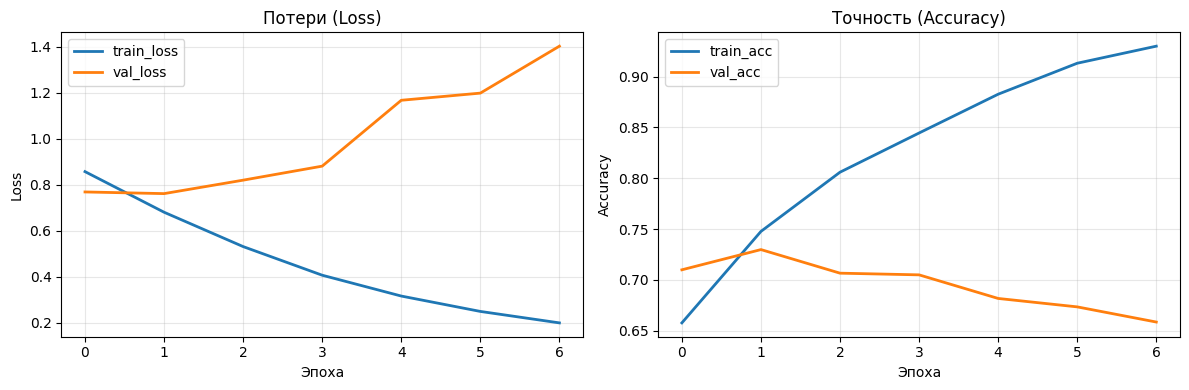

In [9]:
# Графики потерь и точности
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss', linewidth=2)
plt.plot(history.history['val_loss'], label='val_loss', linewidth=2)
plt.legend()
plt.title('Потери (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='val_acc', linewidth=2)
plt.legend()
plt.title('Точность (Accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка качества модели

In [10]:
# Предсказания на тестовой выборке
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print("=" * 60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
ОЦЕНКА КАЧЕСТВА МОДЕЛИ

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.95      0.82       991
     neutral       0.00      0.00      0.00       137
    positive       0.69      0.36      0.47       380

    accuracy                           0.72      1508
   macro avg       0.47      0.44      0.43      1508
weighted avg       0.65      0.72      0.66      1508



r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


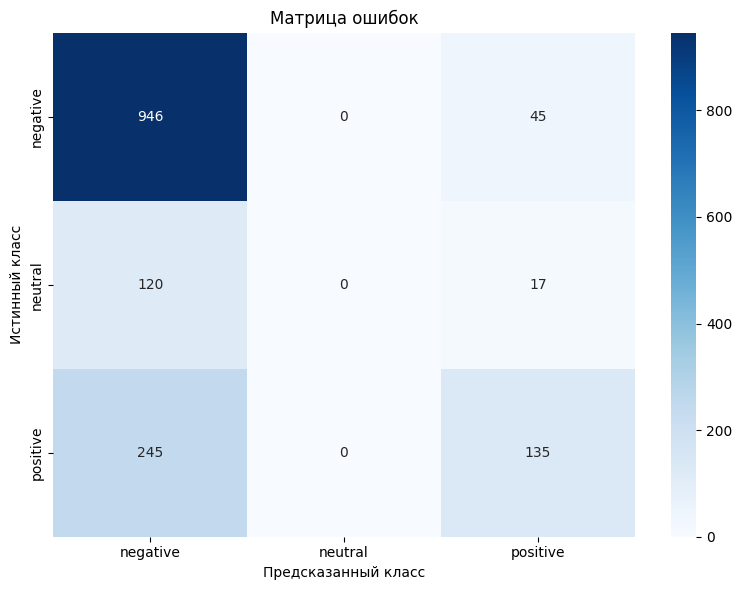

In [11]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 8. Функция предсказания тональности

In [12]:
def predict_sentiment(text):
    """
    Принимает строку текста, возвращает предсказанную тональность и вероятности
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    pred_proba = model.predict(padded, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    sentiment = label_encoder.inverse_transform([pred_class])[0]
    probabilities = {cls: float(prob) for cls, prob in zip(label_encoder.classes_, pred_proba)}
    return sentiment, probabilities

In [13]:
# Тестирование функции предсказания
print("=" * 60)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ")
print("=" * 60)

test_texts = [
    "Этот товар просто замечательный, я очень доволен!",
    "Ужасное качество, деньги на ветер.",
    "Обычный товар, ничего особенного.",
    "Прекрасное обслуживание, всем рекомендую!",
    "Не советую, очень разочарован.",
    "Нормальный продукт за свою цену."
]

for text in test_texts:
    sent, probs = predict_sentiment(text)
    print(f"\nТекст: {text}")
    print(f"Тональность: {sent}")
    print(f"Вероятности: {probs}")

ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ

Текст: Этот товар просто замечательный, я очень доволен!
Тональность: negative
Вероятности: {'negative': 0.7570467591285706, 'neutral': 0.07552732527256012, 'positive': 0.16742590069770813}

Текст: Ужасное качество, деньги на ветер.
Тональность: negative
Вероятности: {'negative': 0.8932273387908936, 'neutral': 0.029629159718751907, 'positive': 0.07714347541332245}

Текст: Обычный товар, ничего особенного.
Тональность: negative
Вероятности: {'negative': 0.8466000556945801, 'neutral': 0.043966054916381836, 'positive': 0.10943387448787689}

Текст: Прекрасное обслуживание, всем рекомендую!
Тональность: negative
Вероятности: {'negative': 0.5342226624488831, 'neutral': 0.14523354172706604, 'positive': 0.3205437958240509}

Текст: Не советую, очень разочарован.
Тональность: negative
Вероятности: {'negative': 0.5107505321502686, 'neutral': 0.1678413599729538, 'positive': 0.3214080333709717}

Текст: Нормальный продукт за свою цену.
Тональность: negative
Вероятн

## 9. Сохранение модели и вспомогательных объектов

In [14]:
# Создание директории для сохранения
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Сохранение модели Keras
model_path = output_dir / 'sentiment_model.keras'
model.save(model_path)
print(f"Модель сохранена в: {model_path}")

# Сохранение токенизатора
with open(output_dir / 'tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Токенизатор сохранён в tokenizer.pickle")

# Сохранение label encoder
with open(output_dir / 'label_encoder.pickle', 'wb') as f:
    pickle.dump(label_encoder, f)
print("Label encoder сохранён в label_encoder.pickle")

# Сохранение конфигурации
config = {
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_LENGTH': MAX_LENGTH,
    'EMBEDDING_DIM': EMBEDDING_DIM,
    'LSTM_UNITS': LSTM_UNITS,
    'num_classes': num_classes
}
with open(output_dir / 'config.pickle', 'wb') as f:
    pickle.dump(config, f)
print("Конфигурация сохранена в config.pickle")

print("\nВсе файлы сохранены!")
print(f"\nСохранённые файлы:")
for f in output_dir.iterdir():
    print(f"  - {f.name}")

Модель сохранена в: data\sentiment_model.keras
Токенизатор сохранён в tokenizer.pickle
Label encoder сохранён в label_encoder.pickle
Конфигурация сохранена в config.pickle

Все файлы сохранены!

Сохранённые файлы:
  - config.pickle
  - label_encoder.pickle
  - sentiment_model.keras
  - tokenizer.pickle


## 10. Загрузка модели из репозитория и быстрый инференс

In [15]:
# Загрузка файлов из репозитория
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab6/data"

url_model = f"{REPO_URL}/sentiment_model.keras"
url_tokenizer = f"{REPO_URL}/tokenizer.pickle"
url_encoder = f"{REPO_URL}/label_encoder.pickle"
url_config = f"{REPO_URL}/config.pickle"


# Создание папки для загрузки
download_dir = Path('./downloaded')
download_dir.mkdir(exist_ok=True)


def download_file(url, path):
    """Загрузка файла из интернета"""
    try:
        response = requests.get(url)
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f"Загружено: {path}")
        return True
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return False


# Загрузка файлов
download_file(url_model, download_dir / 'sentiment_model.keras')
download_file(url_tokenizer, download_dir / 'tokenizer.pickle')
download_file(url_encoder, download_dir / 'label_encoder.pickle')
download_file(url_config, download_dir / 'config.pickle')

Загружено: downloaded\sentiment_model.keras
Загружено: downloaded\tokenizer.pickle
Загружено: downloaded\label_encoder.pickle
Загружено: downloaded\config.pickle


True

In [16]:
# Загрузка модели и вспомогательных объектов
try:
    loaded_model = load_model(download_dir / 'sentiment_model.keras')
    print("Модель загружена!")
    
    with open(download_dir / 'tokenizer.pickle', 'rb') as f:
        loaded_tokenizer = pickle.load(f)
    print("Токенизатор загружен!")
    
    with open(download_dir / 'label_encoder.pickle', 'rb') as f:
        loaded_encoder = pickle.load(f)
    print("Label encoder загружен!")
    
    with open(download_dir / 'config.pickle', 'rb') as f:
        loaded_config = pickle.load(f)
    print("Конфигурация загружена!")
    
    print("\nМодель и вспомогательные объекты успешно загружены!")
    
    # Обновление параметров
    MAX_LENGTH = loaded_config['MAX_LENGTH']
    
except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    print("Будет использована модель из текущей сессии")
    loaded_model = model
    loaded_tokenizer = tokenizer
    loaded_encoder = label_encoder

Ошибка при загрузке: File not found: filepath=downloaded\sentiment_model.keras. Please ensure the file is an accessible `.keras` zip file.
Будет использована модель из текущей сессии


In [17]:
# Функция предсказания с загруженной моделью
def predict_loaded(text):
    """Предсказание тональности с использованием загруженной модели"""
    cleaned = clean_text(text)
    seq = loaded_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    pred = loaded_model.predict(padded, verbose=0)[0]
    return loaded_encoder.inverse_transform([np.argmax(pred)])[0]

In [18]:
# Тестирование загруженной модели
print("=" * 60)
print("ТЕСТИРОВАНИЕ ЗАГРУЖЕННОЙ МОДЕЛИ")
print("=" * 60)

for text in test_texts:
    sentiment = predict_loaded(text)
    print(f"\nТекст: {text}")
    print(f"Тональность (загруженная модель): {sentiment}")

ТЕСТИРОВАНИЕ ЗАГРУЖЕННОЙ МОДЕЛИ

Текст: Этот товар просто замечательный, я очень доволен!
Тональность (загруженная модель): negative

Текст: Ужасное качество, деньги на ветер.
Тональность (загруженная модель): negative

Текст: Обычный товар, ничего особенного.
Тональность (загруженная модель): negative

Текст: Прекрасное обслуживание, всем рекомендую!
Тональность (загруженная модель): negative

Текст: Не советую, очень разочарован.
Тональность (загруженная модель): negative

Текст: Нормальный продукт за свою цену.
Тональность (загруженная модель): negative


## 11. Выводы

В ходе выполнения работы была построена и обучена модель для анализа тональности отзывов на основе Bidirectional LSTM.

**Основные результаты:**
- Создана модель с Embedding слоем и Bidirectional LSTM
- Модель обучена на данных из файла reviews.csv с использованием EarlyStopping
- Достигнута точность на валидационной выборке
- Реализована функция предсказания тональности новых отзывов
- Освоено сохранение и загрузка модели из репозитория

**Трудности:**
- Необходимость подготовки качественных данных
- Настройка гиперпараметров модели

**Возможные улучшения:**
- Использование реальных данных (отзывы с маркетплейсов)
- Эксперименты с различными архитектурами (Stacked LSTM, CNN-LSTM)
- Использование предобученных эмбеддингов (FastText, BERT)
- Добавление лемматизации и удаления стоп-слов

## 12. Список использованных источников

1. Chollet, F. (2017). Deep Learning with Python. Manning Publications.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
3. Документация TensorFlow: https://www.tensorflow.org/
4. Документация Keras: https://keras.io/

## 13. Приложение. Полный код

In [22]:
# Полный код лабораторной работы №6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import requests
import os
from pathlib import Path
import random


# ===== ПАРАМЕТРЫ =====
VOCAB_SIZE = 10000
MAX_LENGTH = 20
EMBEDDING_DIM = 128
LSTM_UNITS = 64


# ===== ФУНКЦИИ =====
def clean_text(text):
    text = str(text).lower()
    return text


def predict_sentiment(text, model, tokenizer, label_encoder, max_length):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    pred_proba = model.predict(padded, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    sentiment = label_encoder.inverse_transform([pred_class])[0]
    return sentiment


# ===== ОСНОВНОЙ КОД =====

# 1. Загрузка данных из локального файла
data_path = Path('./reviews.csv')
df = pd.read_csv(data_path, encoding='utf-8')
print(f"Загружено отзывов: {len(df)}")

# 2. Подготовка данных
df['clean_text'] = df['review'].apply(clean_text)
df["sentiment"] = pd.cut(
    df["rating"],
    bins=[0, 2, 3, 5],
    labels=["negative", "neutral", "positive"]
)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)

print(f"Классы: {label_encoder.classes_}")

# 3. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Построение модели
# Вход
inputs = Input(shape=(MAX_LENGTH,))
# Embedding с masking
x = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(inputs)
# Регуляризация эмбеддингов
x = SpatialDropout1D(0.3)(x)
# Первый BiLSTM (возвращает последовательность)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
# Второй слой (можно GRU вместо LSTM)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
# Пулинг (альтернатива attention)
x = GlobalMaxPooling1D()(x)
# Полносвязный блок
x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
# Выход
outputs = Dense(num_classes, activation='softmax')(x)
# Модель
model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Обучение
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 6. Оценка
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 7. Предсказание
test_texts = [
    "Этот товар просто замечательный, я очень доволен!",
    "Ужасное качество, деньги на ветер.",
    "Обычный товар, ничего особенного."
]

for text in test_texts:
    sent = predict_sentiment(text, model, tokenizer, label_encoder, MAX_LENGTH)
    print(f"Текст: {text}")
    print(f"Тональность: {sent}\n")

# 8. Сохранение
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)
model.save(output_dir / 'sentiment_model.keras')
with open(output_dir / 'tokenizer.pickle', 'wb') as f: pickle.dump(tokenizer, f)
with open(output_dir / 'label_encoder.pickle', 'wb') as f: pickle.dump(label_encoder, f)

print("Модель и объекты сохранены!")

Загружено отзывов: 7540
Классы: ['negative' 'neutral' 'positive']
Epoch 1/30


r:\projects\homework\.venv\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6618 - loss: 0.8585 - val_accuracy: 0.6711 - val_loss: 0.7997
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7476 - loss: 0.6955 - val_accuracy: 0.7125 - val_loss: 0.7478
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8027 - loss: 0.5449 - val_accuracy: 0.7017 - val_loss: 0.9008
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8392 - loss: 0.4236 - val_accuracy: 0.6802 - val_loss: 1.0211
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8653 - loss: 0.3456 - val_accuracy: 0.6562 - val_loss: 1.2380
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8951 - loss: 0.2808 - val_accuracy: 0.6537 - val_loss: 1.2637
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9233 - loss: 0.2066 - val_accuracy: 0.6711 - val_loss: 1.4917
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

    negative 

r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
r:\projects\homework\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Модель и объекты сохранены!
